In [11]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from rdkit import Chem
from IPython.display import display
from pathlib import Path

import sys
sys.path.append("../scripts/")
from data_utils import dfUtils
from smiles_utils import *

import matplotlib.pyplot as plt
import seaborn as sns

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


mol to structure converter:
https://www.cheminfo.org/flavor/malaria/Utilities/SMILES_generator___checker/index.html

generated il smiles: CCCCn1cc[n+](C)c1.F[B-](F)(F)F
sanitized cation smiles: CCCCn1cc[n+](C)c1
sanitized anion smiles: F[B-](F)(F)F
sanitized il smiles: CCCCn1cc[n+](C)c1.F[B-](F)(F)F


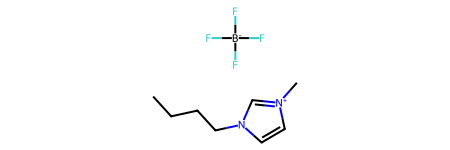

In [5]:
cation_smiles = "CCCCn1cc[n+](C)c1"
anion_smiles = "F[B-](F)(F)F"
il_smiles = cation_smiles + "." + anion_smiles
print(f"generated il smiles: {il_smiles}")

sanitized_cation_smiles = sanitized_smiles(cation_smiles)
print(f"sanitized cation smiles: {sanitized_cation_smiles}")
sanitized_anion_smiles = sanitized_smiles(anion_smiles)
print(f"sanitized anion smiles: {sanitized_anion_smiles}")

sanitized_il_smiles = sanitized_smiles(il_smiles)
print(f"sanitized il smiles: {sanitized_il_smiles}")
mol = Chem.MolFromSmiles(sanitized_il_smiles)
display(mol)

## Scan VISPILS dataset

In [6]:
df = pd.read_csv("../../vispils/data/data_vispils.csv")

In [7]:
df = dfUtils(df)
df.data_summary()


====== data summary ======

Total data points (20252)
Unique IL SMILES (2951)
Unique temperatures (25): [253.0, 253.15, 253.2, 258.15, 259.9, 262.61, 262.7, 263.1, 263.15, 263.42, 264.05, 264.25, 264.5, 264.9, 265.1, 265.65, 265.94, 266.6, 266.77, 267.3, 267.59, 268.0, 268.15, 268.41, 269.1]
Columns (12): Index(['Dataset', 'Iso SMILES', 'cSMILES', 'aSMILES', 'Pressure',
       'Temperature', 'Log viscosity', 'Viscosity', 'cfam', 'afam', 'cvolume',
       'avolume'],
      dtype='object')


,Dataset,Iso SMILES,cSMILES,aSMILES,Pressure,Temperature,Log viscosity,Viscosity,cfam,afam,cvolume,avolume
0,ILthermo,CN(C)C=O.O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,CN(C)C=O,O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,0.10135,273.15,2.030195,107.20,,ntf,0.063976,0.155344
1,ILthermo,CN(C)C=O.O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,CN(C)C=O,O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,0.10135,278.15,1.900367,79.50,,ntf,0.063976,0.155344
2,ILthermo,CN(C)C=O.O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,CN(C)C=O,O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,0.10135,283.15,1.782473,60.60,,ntf,0.063976,0.155344
3,ILthermo,CN(C)C=O.O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,CN(C)C=O,O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,0.10135,288.15,1.675778,47.40,,ntf,0.063976,0.155344
4,ILthermo,CN(C)C=O.O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,CN(C)C=O,O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,0.10135,293.15,1.578983,37.93,,ntf,0.063976,0.155344


In [8]:
df_query = df[df["Iso SMILES"]==sanitized_il_smiles]

df_query = dfUtils(df_query)
df_query.data_summary(il_smiles_col="Iso SMILES", temp_col="Temperature")
df_query.sanitize_old_df(inplace=True)
df_query.data_summary(il_smiles_col="sanitized_smiles", temp_col="temperature_k")


====== data summary ======

Total data points (31)
Unique IL SMILES (1)
Unique temperatures (25): [273.15, 278.15, 283.15, 288.15, 293.15, 294.2, 297.0, 298.15, 303.15, 308.15, 310.0, 313.15, 318.15, 322.0, 323.15, 328.15, 330.0, 331.56, 333.15, 338.15, 341.04, 343.15, 348.15, 350.47, 353.15]
Columns (12): Index(['Dataset', 'Iso SMILES', 'cSMILES', 'aSMILES', 'Pressure',
       'Temperature', 'Log viscosity', 'Viscosity', 'cfam', 'afam', 'cvolume',
       'avolume'],
      dtype='object')


,Dataset,Iso SMILES,cSMILES,aSMILES,Pressure,Temperature,Log viscosity,Viscosity,cfam,afam,cvolume,avolume
3790,Poland,CCCCn1cc[n+](C)c1.F[B-](F)(F)F,CCCCn1cc[n+](C)c1,F[B-](F)(F)F,0.10135,273.15,2.708251,510.80,im,b,0.122336,0.053016
3791,Poland,CCCCn1cc[n+](C)c1.F[B-](F)(F)F,CCCCn1cc[n+](C)c1,F[B-](F)(F)F,0.10135,278.15,2.547652,352.90,im,b,0.122336,0.053016
3792,Poland,CCCCn1cc[n+](C)c1.F[B-](F)(F)F,CCCCn1cc[n+](C)c1,F[B-](F)(F)F,0.10135,283.15,2.406302,254.86,im,b,0.122336,0.053016
3793,Poland,CCCCn1cc[n+](C)c1.F[B-](F)(F)F,CCCCn1cc[n+](C)c1,F[B-](F)(F)F,0.10135,288.15,2.284273,192.43,im,b,0.122336,0.053016
3794,Poland,CCCCn1cc[n+](C)c1.F[B-](F)(F)F,CCCCn1cc[n+](C)c1,F[B-](F)(F)F,0.10135,293.15,2.156912,143.52,im,b,0.122336,0.053016


Renaming 12 columns: ['Dataset', 'Iso SMILES', 'cSMILES', 'aSMILES', 'Pressure', 'Temperature', 'Viscosity', 'Log viscosity', 'cfam', 'afam', 'cvolume', 'avolume']

====== data summary ======

Total data points (31)
Unique IL SMILES (1)
Unique temperatures (25): [273.15, 278.15, 283.15, 288.15, 293.15, 294.2, 297.0, 298.15, 303.15, 308.15, 310.0, 313.15, 318.15, 322.0, 323.15, 328.15, 330.0, 331.56, 333.15, 338.15, 341.04, 343.15, 348.15, 350.47, 353.15]
Columns (12): Index(['reference', 'sanitized_smiles', 'cation_smiles', 'anion_smiles',
       'pressure_atm', 'temperature_k', 'log_10_viscosity_mpas',
       'viscosity_mpas', 'cation_family', 'anion_family',
       'cation_volume_rdkit', 'anion_volume_rdkit'],
      dtype='object')


,reference,sanitized_smiles,cation_smiles,anion_smiles,pressure_atm,temperature_k,log_10_viscosity_mpas,viscosity_mpas,cation_family,anion_family,cation_volume_rdkit,anion_volume_rdkit
3790,Poland,CCCCn1cc[n+](C)c1.F[B-](F)(F)F,CCCCn1cc[n+](C)c1,F[B-](F)(F)F,0.10135,273.15,2.708251,510.80,im,b,0.122336,0.053016
3791,Poland,CCCCn1cc[n+](C)c1.F[B-](F)(F)F,CCCCn1cc[n+](C)c1,F[B-](F)(F)F,0.10135,278.15,2.547652,352.90,im,b,0.122336,0.053016
3792,Poland,CCCCn1cc[n+](C)c1.F[B-](F)(F)F,CCCCn1cc[n+](C)c1,F[B-](F)(F)F,0.10135,283.15,2.406302,254.86,im,b,0.122336,0.053016
3793,Poland,CCCCn1cc[n+](C)c1.F[B-](F)(F)F,CCCCn1cc[n+](C)c1,F[B-](F)(F)F,0.10135,288.15,2.284273,192.43,im,b,0.122336,0.053016
3794,Poland,CCCCn1cc[n+](C)c1.F[B-](F)(F)F,CCCCn1cc[n+](C)c1,F[B-](F)(F)F,0.10135,293.15,2.156912,143.52,im,b,0.122336,0.053016


## Make predictions for queried IL

Steps
- prepare input files according to chemprop & cmpnn
- run trained model with a command
- get predicted results

In [ ]:
from pathlib import Path

def create_prediction_files(il_smiles: str, 
                            temperature_k: float = 298.15, 
                            save_dir=None) -> dict:
    """Create prediction input files for GNN model (CMPNN/Chemprop).

    Generates the necessary input files in the expected format for the CMPNN/Chemprop model.
    Uses pathlib for robust path handling across platforms.
    
    Args:
        il_smiles (str): SMILES string representation of the ionic liquid.
        temperature_k (float): Temperature in Kelvin. Default is 298.15 K (25°C).
        save_dir (str or Path, optional): Directory to save prediction files.
                                          If None, uses './prediction_files'.
                                          Will be created if it doesn't exist.
    
    Returns:
        dict: Dictionary containing paths to created files:
              - 'smiles': Path to SMILES input file
              - 'descriptors': Path to descriptors input file
              - 'output': Path where predictions will be saved
    
    Raises:
        ValueError: If il_smiles is empty or temperature_k is not positive.
        OSError: If files cannot be created due to permission or filesystem issues.
    
    Example:
        >>> paths = create_prediction_files(
        ...     il_smiles="CCCCn1cc[n+](C)c1.F[B-](F)(F)F",
        ...     temperature_k=298.15,
        ...     save_dir="./prediction_files"
        ... )
        >>> print(paths['smiles'])
        Path('prediction_files/data-smis.csv')
    """
    
    # Input validation
    if not il_smiles or not isinstance(il_smiles, str):
        raise ValueError(f"il_smiles must be a non-empty string, got: {il_smiles}")
    
    if temperature_k <= 0:
        raise ValueError(f"temperature_k must be positive, got: {temperature_k}")
    
    # Convert to Path object and handle default
    if save_dir is None:
        save_dir = Path("./prediction_files")
    else:
        save_dir = Path(save_dir)
    
    # Create directory if it doesn't exist
    try:
        save_dir.mkdir(parents=True, exist_ok=True)
        print(f"✓ Prediction directory ready: {save_dir.resolve()}")
    except OSError as e:
        raise OSError(f"Failed to create directory {save_dir}: {e}")
    
    # Define file paths
    smis_path = save_dir / "data-smis.csv"
    descs_path = save_dir / "data-descs.csv"
    predict_out_path = save_dir / "Predict.csv"
    
    try:
        # Write SMILES file
        with open(smis_path, "w") as smis_f:
            smis_f.write("il_smiles,log_10_viscosity_mpas\n")
            smis_f.write(f"{il_smiles},0\n")
        print(f"✓ Created SMILES file: {smis_path}")
        
        # Write descriptors file
        with open(descs_path, "w") as descs_f:
            descs_f.write("temperature_k\n")
            descs_f.write(f"{temperature_k}\n")
        print(f"✓ Created descriptors file: {descs_path}")
        
        print(f"✓ Predictions will be saved to: {predict_out_path}")
        
    except OSError as e:
        raise OSError(f"Failed to write prediction files: {e}")
    
    return {
        'smiles': smis_path,
        'descriptors': descs_path,
        'output': predict_out_path,
        'directory': save_dir
    }


# Create prediction files
prediction_paths = create_prediction_files(
    il_smiles=sanitized_il_smiles,
    temperature_k=298.15,
    save_dir="./prediction_files"
)

print("\n=== Prediction Files Ready ===")
for key, path in prediction_paths.items():
    print(f"{key}: {path}")


FileNotFoundError: [Errno 2] No such file or directory: './prediction_files/data-smis.csv'